<a href="https://colab.research.google.com/github/HoaiNam2k5/Lab03_ANN/blob/main/ANN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  THỰC HÀNH 3: ARTIFICIAL NEURAL NETWORK
# Nhận Dạng Chữ Viết Số Bằng ANN trên Bộ Dataset MNIST

## Giới thiệu
Trong notebook này, chúng ta sẽ xây dựng mạng nơ-ron nhân tạo **(ANN)** để nhận dạng chữ số viết tay từ bộ dữ liệu **MNIST** do giảng viên cung cấp.

### Các nhãn trong bộ dữ liệu:
| Label | Nhãn |
|-------|------|
| 0 | Số 0 |
| 1 | Số 1 |
| 2 | Số 2 |
| 3 | Số 3 |
| 4 | Số 4 |
| 5 | Số 5 |
| 6 | Số 6 |
| 7 | Số 7 |
| 8 | Số 8 |
| 9 | Số 9 |

### Các bước thực hiện:
1. Cài đặt và import thư viện
2. Tải dữ liệu MNIST (từ file giảng viên cung cấp hoặc Keras)
3. Khám phá và trực quan hóa dữ liệu
4. Tiền xử lý dữ liệu
5. Xây dựng mô hình ANN
6. Huấn luyện mô hình
7. Đánh giá mô hình
8. Dự đoán và trực quan hóa kết quả

---
## Bước 1: Import Thư Viện

Import tất cả các thư viện cần thiết cho bài toán nhận dạng chữ số.

In [1]:
# ============================================================
# IMPORT CÁC THƯ VIỆN CẦN THIẾT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Scikit-learn
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ---- Kiểm tra môi trường ----
print(f" TensorFlow version : {tf.__version__}")
print(f" NumPy version      : {np.__version__}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" GPU available      : {gpus[0].name}")
else:
    print("  Không có GPU — đang dùng CPU")

# Seed để tái tạo kết quả
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
print(f"\n🎲 Random seed đã đặt: {SEED}")

 TensorFlow version : 2.20.0
 NumPy version      : 2.0.2
 GPU available      : /physical_device:GPU:0

🎲 Random seed đã đặt: 42


---
## Bước 2: Tải Dữ Liệu MNIST

Notebook hỗ trợ **2 cách** tải dữ liệu:
- **Cách A**: Từ file `.npz` / `.csv` do **giảng viên cung cấp** (ưu tiên)
- **Cách B**: Tự động tải từ Keras (dự phòng nếu không có file)

> 📌 **Hướng dẫn**: Nếu có file dữ liệu từ giảng viên, upload lên Colab rồi chỉnh `DATA_PATH` bên dưới.

In [2]:
# ============================================================
# TẢI DỮ LIỆU MNIST
# ============================================================

# ---- CÁCH A: Từ file do giảng viên cung cấp ----
# Đổi đường dẫn phù hợp với file bạn đã upload
# Ví dụ: DATA_PATH = '/content/mnist.npz'
#        DATA_PATH = '/content/mnist_train.csv'

DATA_PATH = '/content/mnist.npz'   # <-- Thay đường dẫn nếu cần

data_loaded_from_file = False

if os.path.exists(DATA_PATH):
    print(f" Tìm thấy file: {DATA_PATH}")

    if DATA_PATH.endswith('.npz'):
        # Định dạng NumPy .npz
        data = np.load(DATA_PATH)
        print(f"   Keys trong file: {list(data.keys())}")
        # Điều chỉnh key theo file thực tế
        X_train = data.get('x_train', data.get('X_train', data.get('train_images')))
        y_train = data.get('y_train', data.get('Y_train', data.get('train_labels')))
        X_test  = data.get('x_test',  data.get('X_test',  data.get('test_images')))
        y_test  = data.get('y_test',  data.get('Y_test',  data.get('test_labels')))

    elif DATA_PATH.endswith('.csv'):
        # Định dạng CSV: cột đầu là label, còn lại là pixel
        df = pd.read_csv(DATA_PATH)
        print(f"   Shape DataFrame: {df.shape}")
        labels = df.iloc[:, 0].values
        pixels = df.iloc[:, 1:].values.reshape(-1, 28, 28)
        # Chia 80% train / 20% test
        split  = int(len(pixels) * 0.8)
        X_train, X_test = pixels[:split], pixels[split:]
        y_train, y_test = labels[:split], labels[split:]

    data_loaded_from_file = True
    print(" Tải dữ liệu từ file thành công!")

else:
    # ---- CÁCH B: Tải từ Keras (dự phòng) ----
    print("  Không tìm thấy file giảng viên.")
    print("    Tự động tải MNIST từ Keras...")
    (X_train, y_train), (X_test, y_test) = mnist.load_data()
    print(" Tải dữ liệu từ Keras thành công!")

# ---- Thông tin dữ liệu ----
print(f"\n Thông tin dữ liệu:")
print(f"   X_train shape : {X_train.shape}")
print(f"   y_train shape : {y_train.shape}")
print(f"   X_test  shape : {X_test.shape}")
print(f"   y_test  shape : {y_test.shape}")
print(f"   Pixel range   : [{X_train.min()}, {X_train.max()}]")
print(f"   Số lớp        : {len(np.unique(y_train))} lớp {sorted(np.unique(y_train))}")

# Tên nhãn
class_names = [f'Số {i}' for i in range(10)]

  Không tìm thấy file giảng viên.
    Tự động tải MNIST từ Keras...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
 Tải dữ liệu từ Keras thành công!

 Thông tin dữ liệu:
   X_train shape : (60000, 28, 28)
   y_train shape : (60000,)
   X_test  shape : (10000, 28, 28)
   y_test  shape : (10000,)
   Pixel range   : [0, 255]
   Số lớp        : 10 lớp [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9)]


---
## Bước 3: Khám Phá và Trực Quan Hóa Dữ Liệu

Quan sát dữ liệu trước khi huấn luyện giúp hiểu rõ đặc điểm của bộ dữ liệu.

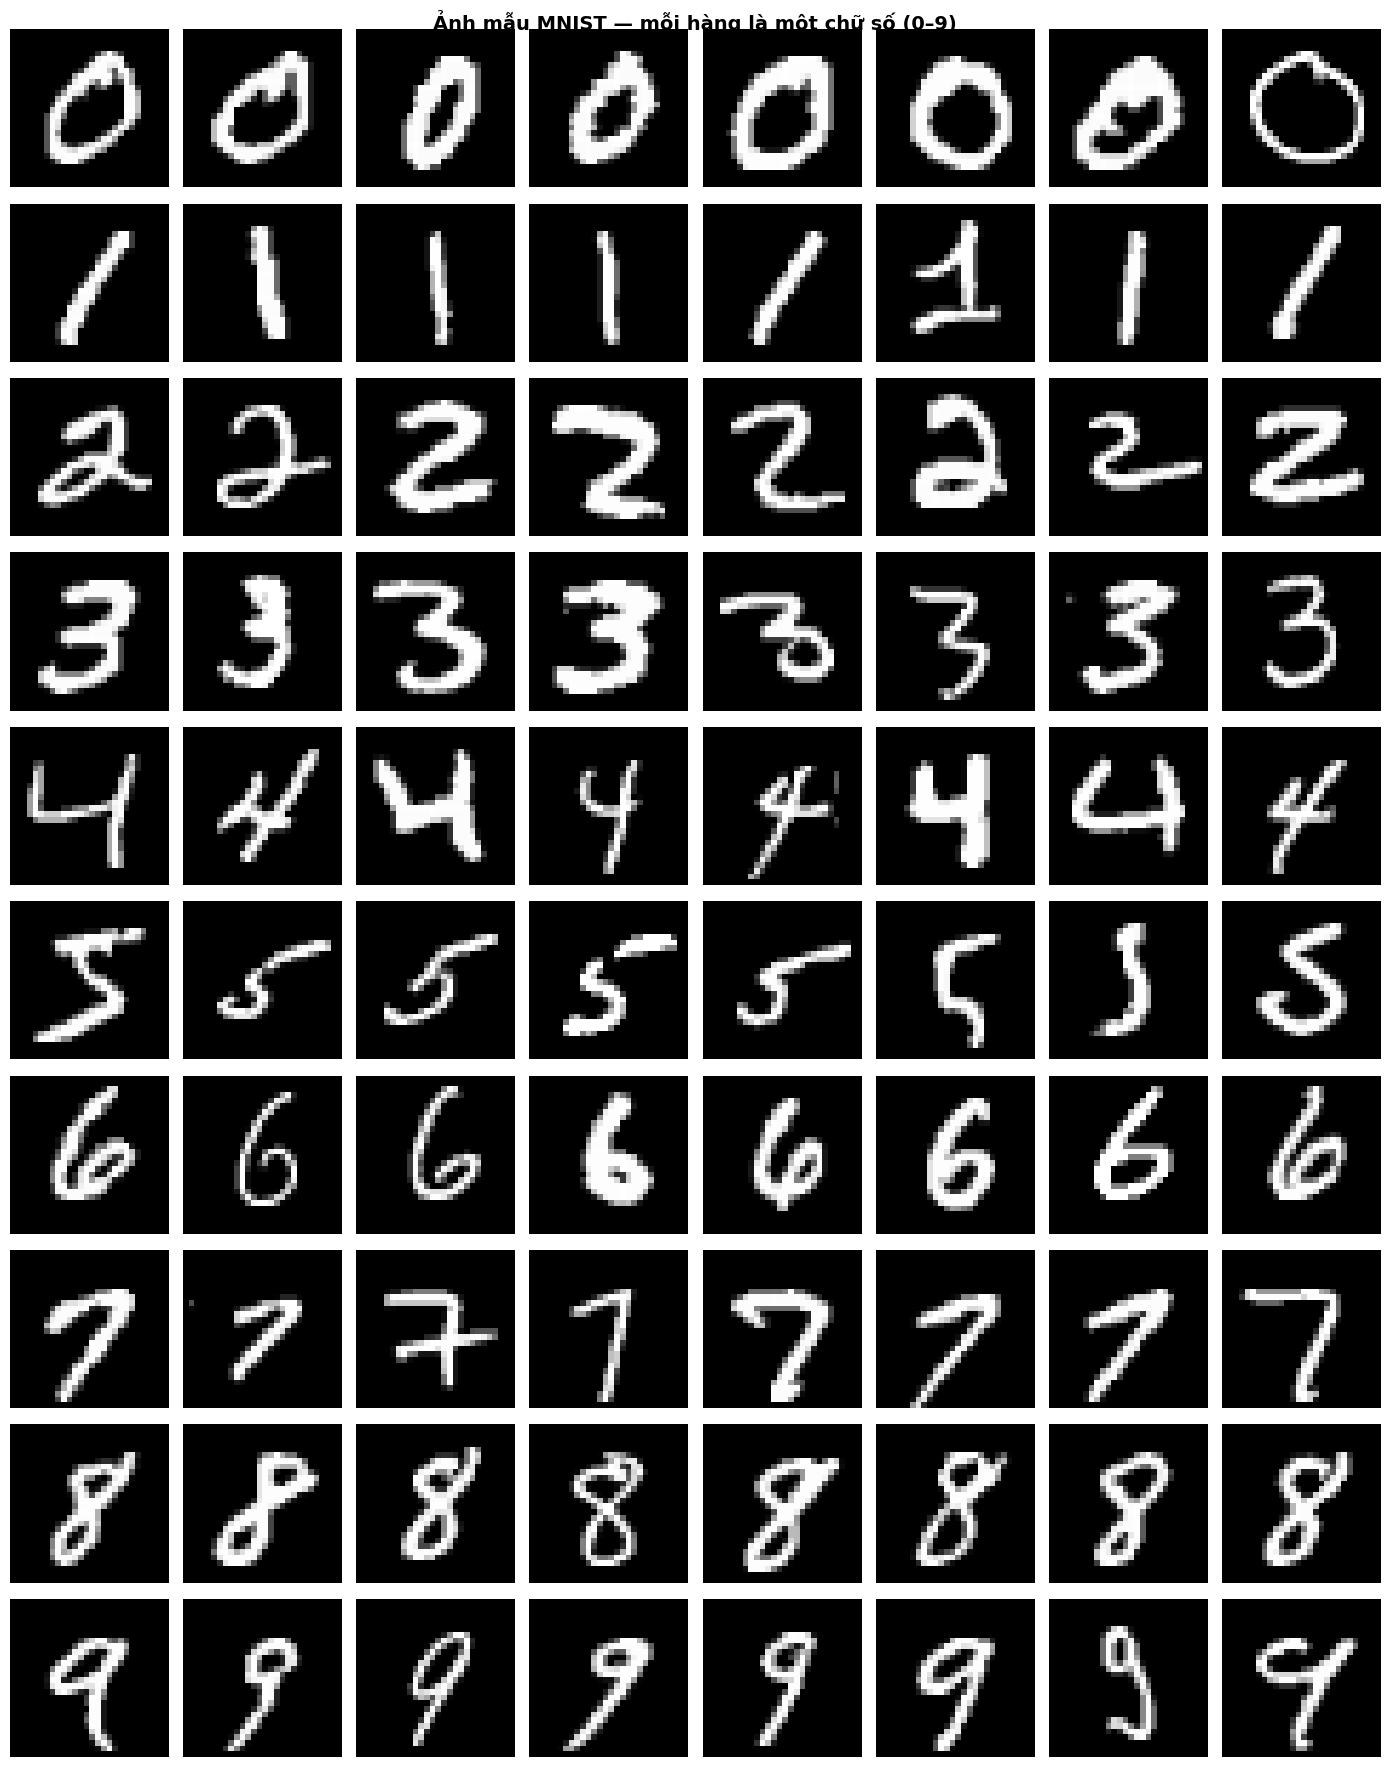

In [3]:
# ============================================================
# HIỂN THỊ ẢNH MẪU — 10 chữ số, mỗi số 8 ảnh
# ============================================================

fig, axes = plt.subplots(10, 8, figsize=(14, 18))
fig.suptitle('Ảnh mẫu MNIST — mỗi hàng là một chữ số (0–9)', fontsize=14, fontweight='bold')

for digit in range(10):
    idx_list = np.where(y_train.flatten() == digit)[0][:8]
    for col, idx in enumerate(idx_list):
        ax = axes[digit][col]
        ax.imshow(X_train[idx], cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'Số {digit}', fontsize=10, rotation=0,
                          labelpad=30, va='center', fontweight='bold')

plt.tight_layout()
plt.show()

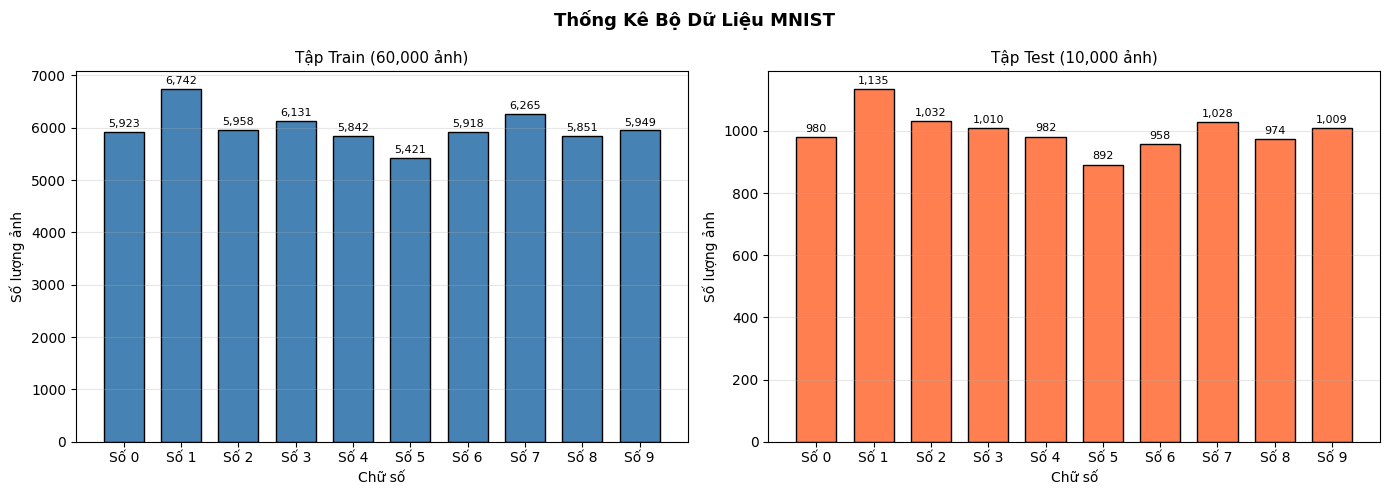


 Bảng phân phối nhãn:
Nhãn          Train     Test    Tỉ lệ Train
--------------------------------------------
Số 0          5,923      980           9.9%
Số 1          6,742    1,135          11.2%
Số 2          5,958    1,032           9.9%
Số 3          6,131    1,010          10.2%
Số 4          5,842      982           9.7%
Số 5          5,421      892           9.0%
Số 6          5,918      958           9.9%
Số 7          6,265    1,028          10.4%
Số 8          5,851      974           9.8%
Số 9          5,949    1,009           9.9%
--------------------------------------------
Tổng         60,000   10,000         100.0%


In [4]:
# ============================================================
# PHÂN PHỐI NHÃN VÀ THỐNG KÊ DỮ LIỆU
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Thống Kê Bộ Dữ Liệu MNIST', fontsize=13, fontweight='bold')

# Train set
unique_tr, counts_tr = np.unique(y_train.flatten(), return_counts=True)
bars1 = axes[0].bar([f'Số {i}' for i in unique_tr], counts_tr,
                    color='steelblue', edgecolor='black', width=0.7)
axes[0].set_title(f'Tập Train ({len(X_train):,} ảnh)', fontsize=11)
axes[0].set_xlabel('Chữ số')
axes[0].set_ylabel('Số lượng ảnh')
for bar, cnt in zip(bars1, counts_tr):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Test set
unique_te, counts_te = np.unique(y_test.flatten(), return_counts=True)
bars2 = axes[1].bar([f'Số {i}' for i in unique_te], counts_te,
                    color='coral', edgecolor='black', width=0.7)
axes[1].set_title(f'Tập Test ({len(X_test):,} ảnh)', fontsize=11)
axes[1].set_xlabel('Chữ số')
axes[1].set_ylabel('Số lượng ảnh')
for bar, cnt in zip(bars2, counts_te):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Bảng thống kê
print("\n Bảng phân phối nhãn:")
print(f"{'Nhãn':<8} {'Train':>10} {'Test':>8} {'Tỉ lệ Train':>14}")
print("-"*44)
for i in range(10):
    print(f"Số {i:<5} {counts_tr[i]:>10,} {counts_te[i]:>8,} {counts_tr[i]/len(y_train)*100:>13.1f}%")
print("-"*44)
print(f"{'Tổng':<8} {len(y_train):>10,} {len(y_test):>8,} {'100.0%':>14}")

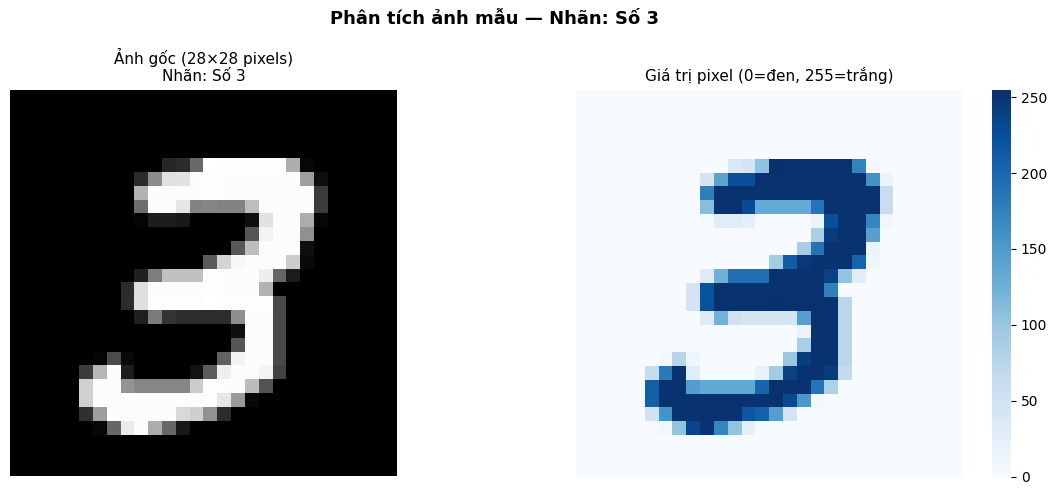

   Shape ảnh   : (28, 28)
   Pixel min   : 0
   Pixel max   : 255
   Pixel mean  : 45.75


In [5]:
# ============================================================
# QUAN SÁT GIÁ TRỊ PIXEL CỦA MỘT ẢNH MẪU
# ============================================================
# Giúp hiểu ảnh MNIST là ma trận 28x28 giá trị từ 0 đến 255

sample_idx   = 7
sample_img   = X_train[sample_idx]
sample_label = y_train.flatten()[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Phân tích ảnh mẫu — Nhãn: Số {sample_label}', fontsize=13, fontweight='bold')

# Ảnh gốc
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f'Ảnh gốc (28×28 pixels)\nNhãn: Số {sample_label}', fontsize=11)
axes[0].axis('off')

# Heatmap giá trị pixel
sns.heatmap(sample_img, ax=axes[1], cmap='Blues',
            annot=(sample_img.shape[0] <= 14),
            fmt='d', cbar=True, square=True,
            xticklabels=False, yticklabels=False)
axes[1].set_title('Giá trị pixel (0=đen, 255=trắng)', fontsize=11)

plt.tight_layout()
plt.show()

print(f"   Shape ảnh   : {sample_img.shape}")
print(f"   Pixel min   : {sample_img.min()}")
print(f"   Pixel max   : {sample_img.max()}")
print(f"   Pixel mean  : {sample_img.mean():.2f}")

---
## Bước 4: Tiền Xử Lý Dữ Liệu (Preprocessing)

| Bước | Mô tả | Trước → Sau |
|------|--------|-------------|
| **Normalize** | Chia pixel cho 255 | [0, 255] → [0.0, 1.0] |
| **Flatten** | Làm phẳng ảnh 2D thành vector 1D | (28, 28) → (784,) |
| **One-hot** | Chuyển nhãn số thành vector nhị phân | 3 → [0,0,0,1,0,0,0,0,0,0] |

In [6]:
# ============================================================
# TIỀN XỬ LÝ DỮ LIỆU
# ============================================================

NUM_CLASSES = 10

# ---- 4.1: Chuẩn hóa (Normalize) ----
# Giá trị pixel [0, 255] → [0.0, 1.0]
# Giúp gradient descent hội tụ nhanh và ổn định hơn
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32')  / 255.0

print("[4.1] Chuẩn hóa pixel:")
print(f"      Trước: min={X_train.min()}, max={X_train.max()}")
print(f"      Sau  : min={X_train_norm.min():.2f}, max={X_train_norm.max():.2f}")

# ---- 4.2: Làm phẳng ảnh (Flatten) ----
# ANN Fully Connected cần đầu vào là vector 1D
# 28 x 28 = 784 đặc trưng
X_train_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_test_flat  = X_test_norm.reshape(len(X_test_norm),  -1)

print("\n[4.2] Flatten ảnh:")
print(f"      Trước: {X_train_norm.shape}")
print(f"      Sau  : {X_train_flat.shape}  (60000 ảnh × 784 pixel)")

# ---- 4.3: One-hot Encoding nhãn ----
# Ví dụ: nhãn 5 → [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print("\n[4.3] One-hot encoding:")
print(f"      Nhãn gốc  : {y_train.flatten()[0]}")
print(f"      One-hot   : {y_train_cat[0]}")
print(f"      Shape     : {y_train_cat.shape}")

print("\n Tiền xử lý hoàn tất!")

[4.1] Chuẩn hóa pixel:
      Trước: min=0, max=255
      Sau  : min=0.00, max=1.00

[4.2] Flatten ảnh:
      Trước: (60000, 28, 28)
      Sau  : (60000, 784)  (60000 ảnh × 784 pixel)

[4.3] One-hot encoding:
      Nhãn gốc  : 5
      One-hot   : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
      Shape     : (60000, 10)

 Tiền xử lý hoàn tất!


---
## Bước 5: Xây Dựng Mô Hình ANN

### Kiến trúc mạng:
```
Input Layer   →  784 neurons  (28×28 pixel)
     ↓
Hidden Layer 1 →  512 neurons  + BatchNorm + Dropout(0.3)
     ↓
Hidden Layer 2 →  256 neurons  + BatchNorm + Dropout(0.3)
     ↓
Hidden Layer 3 →  128 neurons  + BatchNorm + Dropout(0.2)
     ↓
Output Layer  →   10 neurons  (softmax — xác suất 10 chữ số)
```

**Hàm kích hoạt ReLU**: `f(x) = max(0, x)` — nhanh, hiệu quả, tránh vanishing gradient  
**Softmax** (output): chuyển logit thành xác suất, tổng = 1.0

In [7]:
# ============================================================
# XÂY DỰNG MÔ HÌNH ANN
# ============================================================

def build_ann_mnist(input_dim=784, num_classes=10):
    """
    Xây dựng ANN cho bài toán nhận dạng chữ số MNIST.

    Kiến trúc:
      Input(784) → Dense(512) → Dense(256) → Dense(128) → Output(10)
      Mỗi hidden layer: BatchNorm + Dropout để chống overfitting

    Args:
        input_dim  : số chiều đầu vào (28*28 = 784)
        num_classes: số lớp phân loại (10 chữ số)
    Returns:
        model: Keras Sequential
    """
    model = models.Sequential(name='ANN_MNIST')

    # ── Input ──────────────────────────────────────────────
    model.add(layers.Input(shape=(input_dim,))  )

    # ── Hidden Layer 1: 512 neurons ────────────────────────
    # Dense: kết nối đầy đủ mỗi neuron với mọi đầu vào
    # ReLU: f(x) = max(0, x) — phổ biến và hiệu quả nhất
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())         # Chuẩn hóa đầu ra từng mini-batch
    model.add(layers.Dropout(0.3))                 # Tắt ngẫu nhiên 30% neuron khi train

    # ── Hidden Layer 2: 256 neurons ────────────────────────
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    # ── Hidden Layer 3: 128 neurons ────────────────────────
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.2))

    # ── Output Layer: 10 neurons ───────────────────────────
    # Softmax: chuyển logit thành xác suất, tổng = 1.0
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


# Tạo mô hình
model = build_ann_mnist(input_dim=784, num_classes=NUM_CLASSES)

# In tóm tắt kiến trúc
model.summary()

Model: "ANN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [8]:
# ============================================================
# COMPILE MÔ HÌNH
# ============================================================
# - optimizer : Adam — tự điều chỉnh learning rate, hội tụ nhanh
# - loss      : categorical_crossentropy — phù hợp phân loại nhiều lớp (one-hot)
# - metrics   : accuracy — đo tỉ lệ dự đoán đúng

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Mô hình đã được compile!")
print(f"   Optimizer    : Adam  (learning_rate=0.001)")
print(f"   Loss function: categorical_crossentropy")
print(f"   Metrics      : accuracy")
print(f"   Total params : {model.count_params():,}")

 Mô hình đã được compile!
   Optimizer    : Adam  (learning_rate=0.001)
   Loss function: categorical_crossentropy
   Metrics      : accuracy
   Total params : 571,018


---
## Bước 6: Huấn Luyện Mô Hình

### Chiến lược huấn luyện:
| Callback | Tác dụng |
|----------|----------|
| **EarlyStopping** | Dừng khi `val_loss` không cải thiện sau 10 epoch |
| **ReduceLROnPlateau** | Giảm learning rate × 0.5 khi `val_loss` không giảm |
| **ModelCheckpoint** | Lưu model tốt nhất theo `val_accuracy` |

In [9]:
# ============================================================
# THIẾT LẬP CALLBACKS
# ============================================================

# 1. EarlyStopping — dừng sớm nếu không cải thiện
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,              # Chờ 10 epoch không cải thiện thì dừng
    restore_best_weights=True, # Khôi phục trọng số tốt nhất sau khi dừng
    verbose=1
)

# 2. ReduceLROnPlateau — giảm learning rate khi chững lại
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,   # Nhân lr với 0.5 (giảm còn 50%)
    patience=5,   # Chờ 5 epoch
    min_lr=1e-6,  # Không giảm dưới 0.000001
    verbose=1
)

# 3. ModelCheckpoint — lưu model tốt nhất
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='best_ann_mnist.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

callbacks = [early_stop, reduce_lr, checkpoint]
print(" Callbacks đã sẵn sàng:")
print("   - EarlyStopping      (patience=10, monitor=val_loss)")
print("   - ReduceLROnPlateau  (patience=5,  factor=0.5)")
print("   - ModelCheckpoint    (save best val_accuracy)")

 Callbacks đã sẵn sàng:
   - EarlyStopping      (patience=10, monitor=val_loss)
   - ReduceLROnPlateau  (patience=5,  factor=0.5)
   - ModelCheckpoint    (save best val_accuracy)


In [10]:
# ============================================================
# HUẤN LUYỆN MÔ HÌNH
# ============================================================
# - epochs       : Số lần duyệt toàn bộ tập train (tối đa)
# - batch_size   : Số ảnh mỗi lần cập nhật trọng số
# - validation_split: Dùng 10% train làm validation trong lúc train

print("🚀 Bắt đầu huấn luyện ANN trên MNIST...")
print("="*60)

history = model.fit(
    X_train_flat, y_train_cat,
    epochs=100,
    batch_size=128,
    validation_split=0.1,   # 10% = 6000 ảnh validation
    callbacks=callbacks,
    verbose=1
)

actual_epochs = len(history.history['loss'])
best_val_acc  = max(history.history['val_accuracy'])

print(f"\n Huấn luyện hoàn tất!")
print(f"   Epochs thực tế  : {actual_epochs}")
print(f"   Best val_accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

🚀 Bắt đầu huấn luyện ANN trên MNIST...
Epoch 1/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9019 - loss: 0.3196 - val_accuracy: 0.9655 - val_loss: 0.1091 - learning_rate: 0.0010
Epoch 2/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9545 - loss: 0.1467 - val_accuracy: 0.9750 - val_loss: 0.0823 - learning_rate: 0.0010
Epoch 3/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9660 - loss: 0.1106 - val_accuracy: 0.9765 - val_loss: 0.0716 - learning_rate: 0.0010
Epoch 4/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9711 - loss: 0.0902 - val_accuracy: 0.9783 - val_loss: 0.0713 - learning_rate: 0.0010
Epoch 5/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9744 - loss: 0.0818 - val_accuracy: 0.9813 - val_loss: 0.0648 - learning_rate: 0.0010
Epoch 6/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9782 - loss: 0.0690 - val_accuracy: 0.9822 - val_loss: 0.0597 - learning_rate: 0.0010
Epoch 7/100
422/422 ━━━━━━━━━━━━━━━━━━━━ 

---
## Bước 7: Đánh Giá Mô Hình

Đánh giá toàn diện mô hình qua:
- **Learning Curves**: quan sát quá trình học
- **Test Accuracy / Loss**: hiệu suất trên dữ liệu chưa thấy
- **Classification Report**: Precision, Recall, F1-score từng lớp
- **Confusion Matrix**: ma trận nhầm lẫn

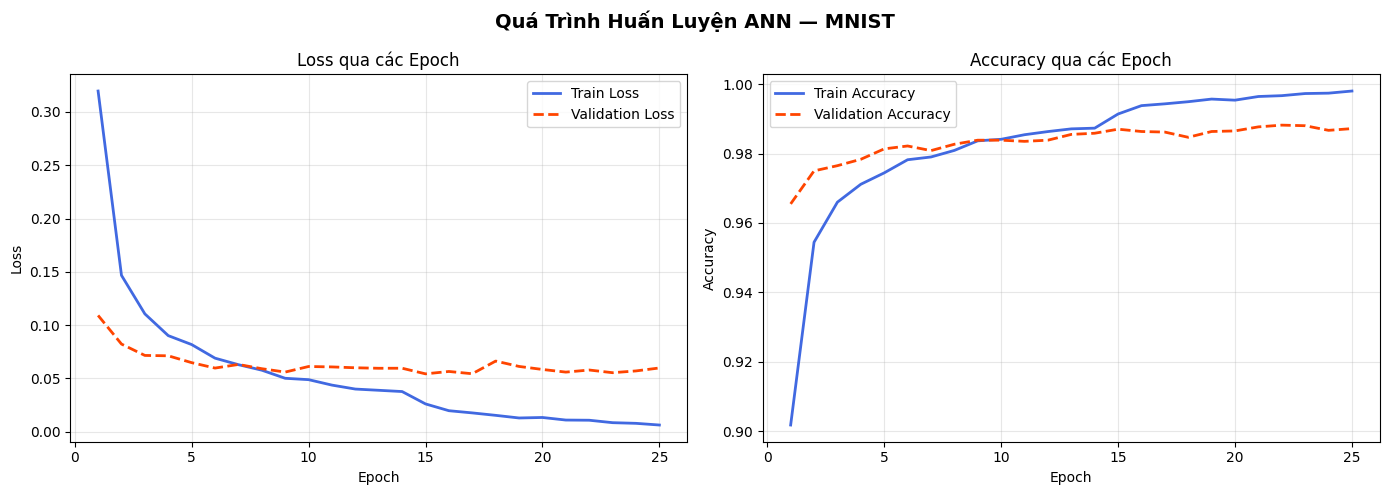

In [11]:
# ============================================================
# ĐƯỜNG CONG HỌC (LEARNING CURVES)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Quá Trình Huấn Luyện ANN — MNIST', fontsize=14, fontweight='bold')

ep = range(1, actual_epochs + 1)

# Loss
axes[0].plot(ep, history.history['loss'],     label='Train Loss',      lw=2, color='royalblue')
axes[0].plot(ep, history.history['val_loss'], label='Validation Loss', lw=2, color='orangered', ls='--')
axes[0].set_title('Loss qua các Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(ep, history.history['accuracy'],     label='Train Accuracy',      lw=2, color='royalblue')
axes[1].plot(ep, history.history['val_accuracy'], label='Validation Accuracy', lw=2, color='orangered', ls='--')
axes[1].set_title('Accuracy qua các Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# ĐÁNH GIÁ TRÊN TẬP TEST
# ============================================================

test_loss, test_acc = model.evaluate(X_test_flat, y_test_cat, verbose=0)

print("="*50)
print("       KẾT QUẢ TRÊN TẬP TEST")
print("="*50)
print(f"  Test Loss    : {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("="*50)

# Dự đoán
y_pred_proba = model.predict(X_test_flat, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = y_test.flatten()

print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

       KẾT QUẢ TRÊN TẬP TEST
  Test Loss    : 0.0539
  Test Accuracy: 0.9853 (98.53%)

 Classification Report:
              precision    recall  f1-score   support

        Số 0       0.99      0.99      0.99       980
        Số 1       0.99      1.00      0.99      1135
        Số 2       0.98      0.99      0.99      1032
        Số 3       0.98      0.99      0.98      1010
        Số 4       0.98      0.98      0.98       982
        Số 5       0.99      0.97      0.98       892
        Số 6       0.99      0.99      0.99       958
        Số 7       0.99      0.98      0.98      1028
        Số 8       0.98      0.99      0.98       974
        Số 9       0.98      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



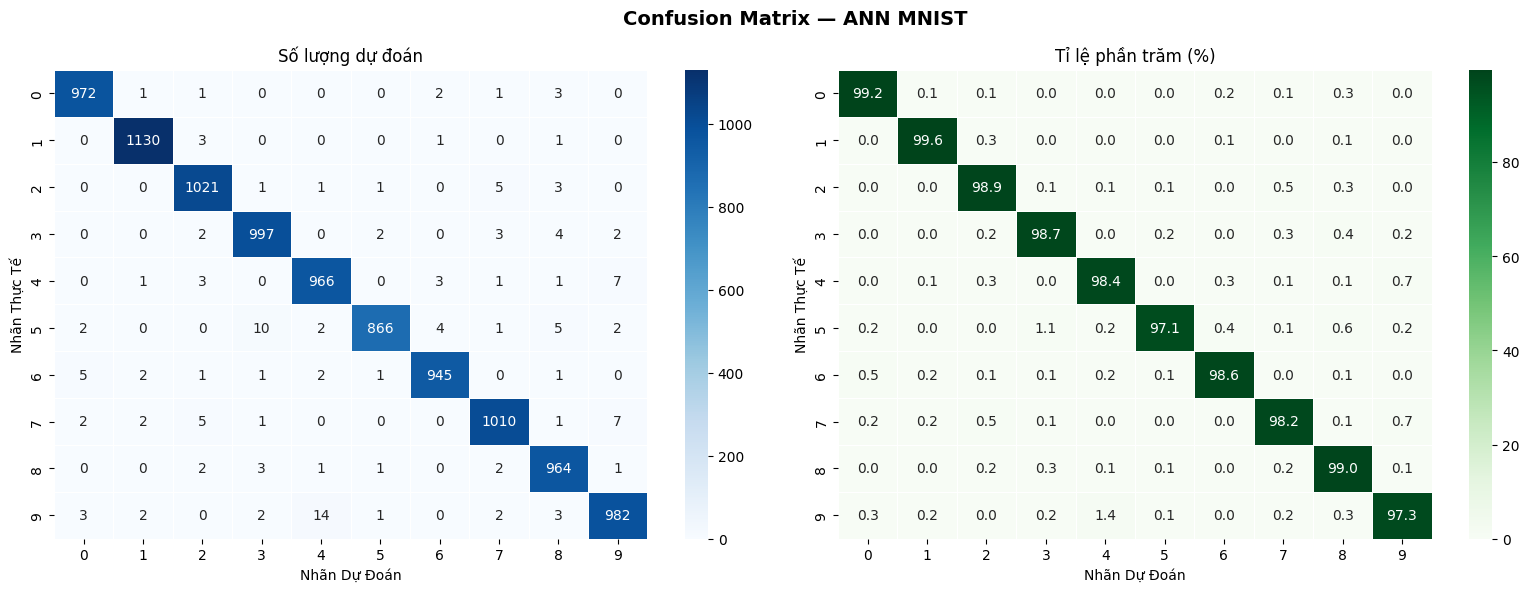


 Accuracy từng chữ số:
----------------------------------------
  Số 0:  99.2%  
  Số 1:  99.6%  
  Số 2:  98.9%  
  Số 3:  98.7%  
  Số 4:  98.4%  
  Số 5:  97.1%  
  Số 6:  98.6%  
  Số 7:  98.2%  
  Số 8:  99.0%  
  Số 9:  97.3%  


In [13]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — ANN MNIST', fontsize=14, fontweight='bold')

# Ma trận số lượng
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Số lượng dự đoán')
axes[0].set_ylabel('Nhãn Thực Tế')
axes[0].set_xlabel('Nhãn Dự Đoán')

# Ma trận phần trăm
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Tỉ lệ phần trăm (%)')
axes[1].set_ylabel('Nhãn Thực Tế')
axes[1].set_xlabel('Nhãn Dự Đoán')

plt.tight_layout()
plt.show()

# Accuracy từng chữ số
print("\n Accuracy từng chữ số:")
print("-"*40)
for i in range(10):
    acc_i = cm[i, i] / cm[i].sum() * 100
    bar   = '' * int(acc_i / 2)
    print(f"  Số {i}: {acc_i:5.1f}%  {bar}")

---
## Bước 8: Dự Đoán và Trực Quan Hóa Kết Quả

Hiển thị ảnh dự đoán đúng/sai và phân tích xác suất của từng chữ số.

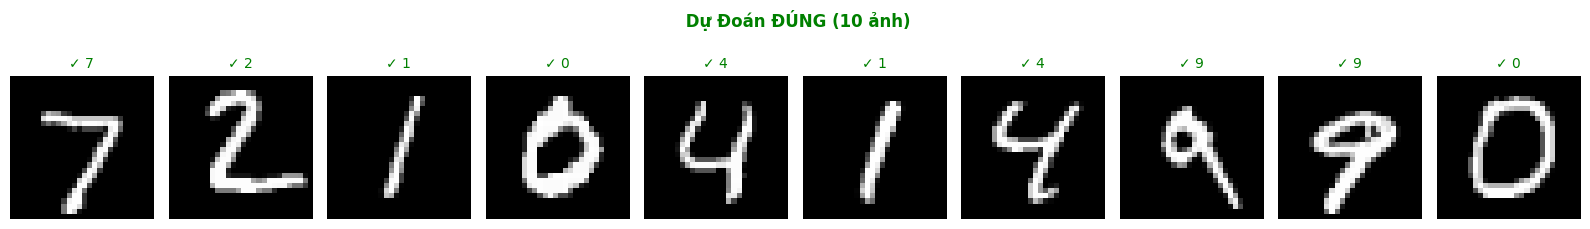

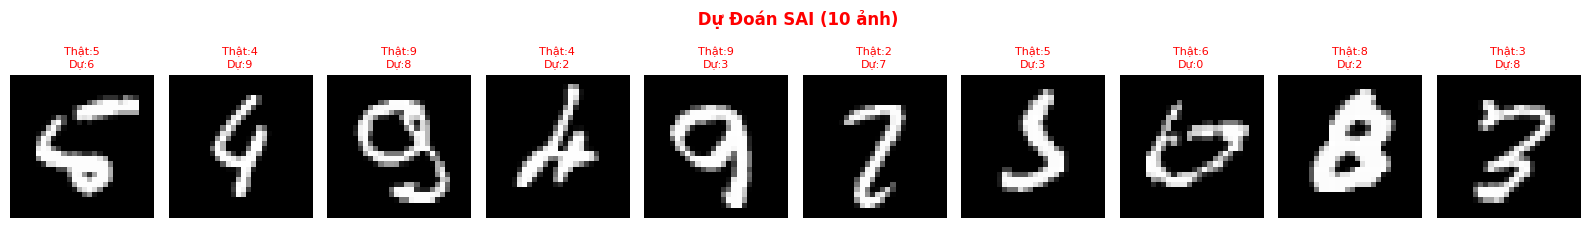

In [14]:
# ============================================================
# HIỂN THỊ ẢNH DỰ ĐOÁN ĐÚNG VÀ SAI
# ============================================================

def plot_predictions(X, y_true, y_pred, n=10, correct=True):
    """
    Hiển thị n ảnh dự đoán đúng hoặc sai.

    Args:
        correct: True → ảnh đúng (viền xanh)
                 False → ảnh sai (viền đỏ)
    """
    mask    = (y_pred == y_true) if correct else (y_pred != y_true)
    indices = np.where(mask)[0][:n]
    color   = 'green' if correct else 'red'
    title   = f" Dự Đoán ĐÚNG ({n} ảnh)" if correct else f" Dự Đoán SAI ({len(indices)} ảnh)"

    if len(indices) == 0:
        print("Không có ảnh phù hợp!")
        return

    cols = min(n, len(indices))
    fig, axes = plt.subplots(1, cols, figsize=(cols * 1.6, 2.5))
    fig.suptitle(title, fontsize=12, fontweight='bold', color=color)
    if cols == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        ax.imshow(X[idx].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if correct:
            ax.set_title(f'✓ {y_pred[idx]}', color='green', fontsize=10)
        else:
            ax.set_title(f'Thật:{y_true[idx]}\nDự:{y_pred[idx]}', color='red', fontsize=8)
        # Viền màu
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

    plt.tight_layout()
    plt.show()

# Ảnh dự đoán ĐÚNG
plot_predictions(X_test_flat, y_true, y_pred, n=10, correct=True)

# Ảnh dự đoán SAI
plot_predictions(X_test_flat, y_true, y_pred, n=10, correct=False)


─── Ảnh index 7653 ───


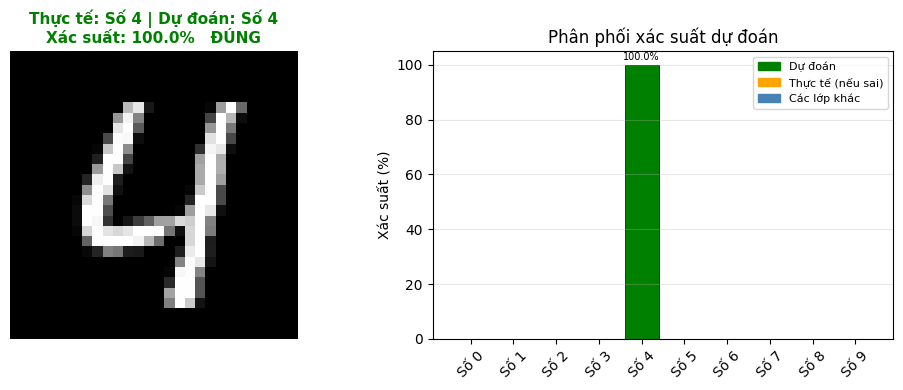


─── Ảnh index 7865 ───


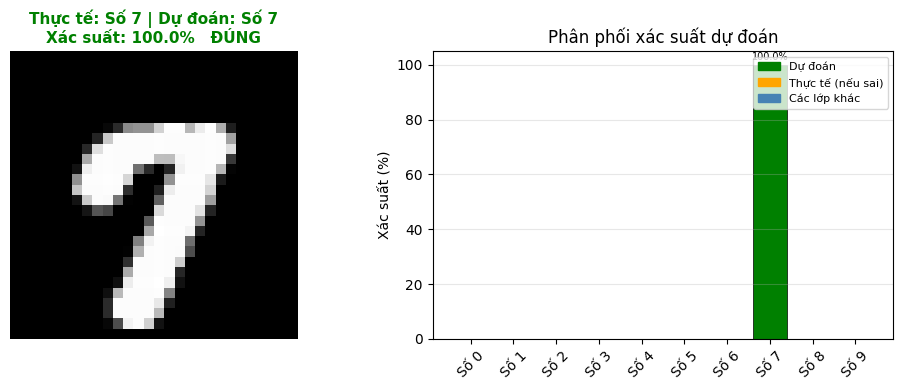


─── Ảnh index 3226 ───


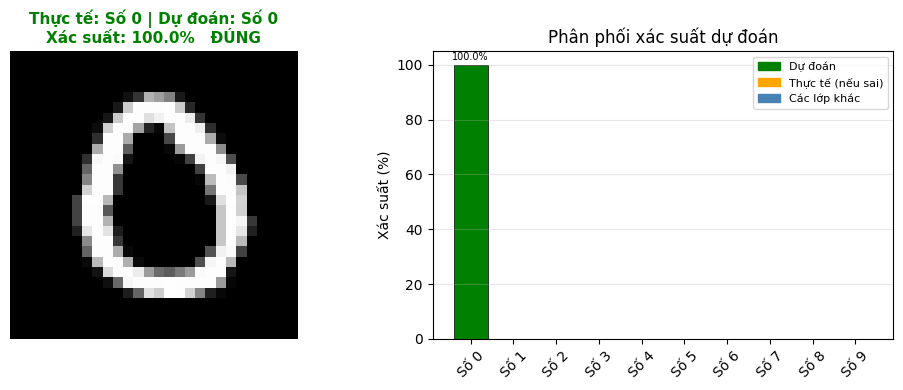

In [15]:
# ============================================================
# DỰ ĐOÁN CHI TIẾT MỘT ẢNH ĐƠN — BIỂU ĐỒ XÁC SUẤT
# ============================================================

def predict_and_show(model, X_flat, X_orig, y_true, idx):
    """
    Dự đoán và hiển thị ảnh + biểu đồ xác suất cho ảnh tại vị trí idx.
    """
    img_flat = X_flat[idx].reshape(1, -1)
    proba    = model.predict(img_flat, verbose=0)[0]
    pred     = np.argmax(proba)
    true_lbl = y_true[idx]
    status   = " ĐÚNG" if pred == true_lbl else " SAI"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Ảnh
    ax1.imshow(X_orig[idx].reshape(28, 28), cmap='gray')
    ax1.axis('off')
    ax1.set_title(
        f"Thực tế: Số {true_lbl} | Dự đoán: Số {pred}\n"
        f"Xác suất: {proba[pred]*100:.1f}%  {status}",
        fontsize=11, fontweight='bold',
        color='green' if pred == true_lbl else 'red'
    )

    # Biểu đồ xác suất
    bar_colors = ['green' if i == pred else ('orange' if i == true_lbl else 'steelblue')
                  for i in range(10)]
    bars = ax2.bar(range(10), proba * 100, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax2.set_xticks(range(10))
    ax2.set_xticklabels([f'Số {i}' for i in range(10)], rotation=45)
    ax2.set_ylabel('Xác suất (%)')
    ax2.set_ylim(0, 105)
    ax2.set_title('Phân phối xác suất dự đoán')
    ax2.grid(axis='y', alpha=0.3)

    # Nhãn trên mỗi cột
    for bar, val in zip(bars, proba * 100):
        if val > 0.5:
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=7)

    # Chú thích màu
    from matplotlib.patches import Patch
    legend = [
        Patch(color='green',     label='Dự đoán'),
        Patch(color='orange',    label='Thực tế (nếu sai)'),
        Patch(color='steelblue', label='Các lớp khác'),
    ]
    ax2.legend(handles=legend, fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.show()


# Thử với 3 ảnh ngẫu nhiên
np.random.seed(99)
sample_ids = np.random.choice(len(X_test_flat), 3, replace=False)

for sid in sample_ids:
    print(f"\n─── Ảnh index {sid} ───")
    predict_and_show(model, X_test_flat, X_test_norm, y_true, sid)

In [16]:
# ============================================================
# DỰ ĐOÁN ẢNH TỪ FILE DO GIẢNG VIÊN CUNG CẤP (tùy chọn)
# ============================================================
# Nếu giảng viên cung cấp ảnh riêng lẻ, dùng cell này để dự đoán

from PIL import Image

def predict_custom_image(model, image_path):
    """
    Dự đoán chữ số từ ảnh tùy chỉnh (file ảnh bất kỳ).

    Args:
        model      : mô hình ANN đã train
        image_path : đường dẫn đến file ảnh (.png, .jpg, ...)
    """
    if not os.path.exists(image_path):
        print(f"❌ Không tìm thấy file: {image_path}")
        return

    # Đọc và tiền xử lý ảnh
    img = Image.open(image_path).convert('L')  # Chuyển sang grayscale
    img = img.resize((28, 28))                  # Resize về 28x28
    img_array = np.array(img).astype('float32') / 255.0
    img_flat  = img_array.flatten().reshape(1, -1)

    # Dự đoán
    proba = model.predict(img_flat, verbose=0)[0]
    pred  = np.argmax(proba)

    # Hiển thị
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_array, cmap='gray')
    ax1.axis('off')
    ax1.set_title(f'Dự đoán: Số {pred}\nXác suất: {proba[pred]*100:.1f}%',
                  fontsize=12, fontweight='bold', color='blue')

    ax2.bar(range(10), proba * 100, color=['green' if i == pred else 'steelblue' for i in range(10)])
    ax2.set_xticks(range(10))
    ax2.set_xticklabels([f'Số {i}' for i in range(10)], rotation=45)
    ax2.set_ylabel('Xác suất (%)')
    ax2.set_title('Phân phối xác suất')
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f" Kết quả dự đoán: Số {pred}  ({proba[pred]*100:.1f}%)")


# ── Sử dụng: đổi đường dẫn đến ảnh của bạn ──
# predict_custom_image(model, '/content/my_digit.png')
print("Để dự đoán ảnh tùy chỉnh, bỏ comment dòng trên và thay đường dẫn file ảnh.")

Để dự đoán ảnh tùy chỉnh, bỏ comment dòng trên và thay đường dẫn file ảnh.


---
## Tổng Kết

### Kết quả:
| Thành phần | Chi tiết |
|-----------|----------|
| Mô hình | ANN — 3 hidden layers (512 → 256 → 128) |
| Input | 784 đặc trưng (28×28 pixel, grayscale) |
| Output | 10 lớp (Số 0 → Số 9, softmax) |
| Chống overfitting | BatchNormalization + Dropout |
| Optimizer | Adam (lr=0.001, ReduceLROnPlateau) |
| Dataset | MNIST (60K train / 10K test) |
| Kỳ vọng accuracy | ~97–98% |

### Nhận xét:
- MNIST là bài toán **tương đối dễ** với ANN vì ảnh grayscale 28×28 đơn giản hơn ảnh màu CIFAR-10
- ANN đạt **~97–98% accuracy** — rất tốt cho mạng fully connected thuần túy
- **CNN** có thể đạt >99% với ít tham số hơn nhờ khai thác cấu trúc không gian của ảnh
- Các chữ số dễ nhầm lẫn nhất thường là: **4↔9**, **3↔8**, **7↔1**

In [17]:
# ============================================================
# IN KẾT QUẢ CUỐI CÙNG
# ============================================================

print("╔" + "═"*50 + "╗")
print("║      KẾT QUẢ CUỐI CÙNG — ANN MNIST         ║")
print("╠" + "═"*50 + "╣")
print(f"║  Test Accuracy  : {test_acc*100:6.2f}%                       ║")
print(f"║  Test Loss      : {test_loss:.4f}                         ║")
print(f"║  Epochs chạy    : {actual_epochs:<5}                          ║")
print(f"║  Total params   : {model.count_params():>10,}                   ║")
print("╚" + "═"*50 + "╝")
print("\n Model tốt nhất đã lưu: best_ann_mnist.keras")

╔══════════════════════════════════════════════════╗
║      KẾT QUẢ CUỐI CÙNG — ANN MNIST         ║
╠══════════════════════════════════════════════════╣
║  Test Accuracy  :  98.53%                       ║
║  Test Loss      : 0.0539                         ║
║  Epochs chạy    : 25                             ║
║  Total params   :    571,018                   ║
╚══════════════════════════════════════════════════╝

 Model tốt nhất đã lưu: best_ann_mnist.keras
